In [1]:
# Import libraries
import os
import re
import random
import warnings
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
# Load dataset
raw = load_dataset("mteb/emotion")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/128k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15956 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1988 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1986 [00:00<?, ? examples/s]

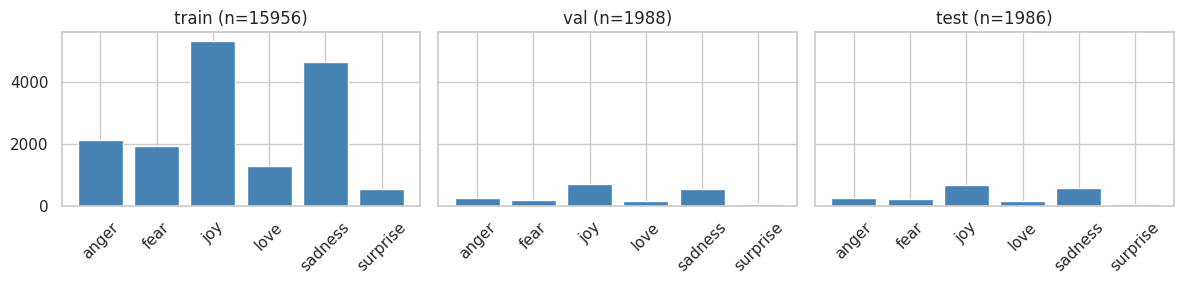

In [3]:
# EDA
def hf_to_df(split_name):
    d = raw[split_name]
    return pd.DataFrame({"text": d["text"], "label": d["label"], "label_text": d["label_text"]})

train_df = hf_to_df("train")
val_df = hf_to_df("validation")
test_df = hf_to_df("test")

# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (name, df) in zip(axes, [("train", train_df), ("val", val_df), ("test", test_df)]):
    vc = df["label_text"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="steelblue")
    ax.set_title(f"{name} (n={len(df)})")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [4]:
def oversample_train_df(train_df, label_col="label", seed=42):
    # Find largest class size
    max_count = train_df[label_col].value_counts().max()

    balanced_parts = []
    for lab, sub in train_df.groupby(label_col):
        # Resample with replacement up to max_count
        up = resample(
            sub,
            replace=True,
            n_samples=max_count,
            random_state=seed
        )
        balanced_parts.append(up)

    balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced_df

train_df_over = oversample_train_df(train_df, label_col="label", seed=SEED)

In [5]:
def undersample_train_df(train_df, label_col="label", seed=42):
    # Find smallest class size
    min_count = train_df[label_col].value_counts().min()

    balanced_parts = []
    for lab, sub in train_df.groupby(label_col):
        down = resample(
            sub,
            replace=False,
            n_samples=min_count,
            random_state=seed
        )
        balanced_parts.append(down)

    balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced_df

train_df_under = undersample_train_df(train_df, label_col="label", seed=SEED)

In [6]:
def moderate_oversample_train_df(train_df, label_col="label", seed=42):
    counts = train_df[label_col].value_counts()
    target = int(np.median(counts.values))

    balanced_parts = []
    for lab, sub in train_df.groupby(label_col):
        if len(sub) < target:
            sub_new = resample(
                sub,
                replace=True,
                n_samples=target,
                random_state=seed
            )
        else:
            sub_new = sub
        balanced_parts.append(sub_new)

    balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced_df

train_df_mod = moderate_oversample_train_df(train_df, label_col="label", seed=SEED)

In [7]:
print(train_df["label"].value_counts().sort_index())
print(train_df_over["label"].value_counts().sort_index())
print(train_df_under["label"].value_counts().sort_index())
print(train_df_mod["label"].value_counts().sort_index())

label
0    4663
1    5345
2    1297
3    2152
4    1931
5     568
Name: count, dtype: int64
label
0    5345
1    5345
2    5345
3    5345
4    5345
5    5345
Name: count, dtype: int64
label
0    568
1    568
2    568
3    568
4    568
5    568
Name: count, dtype: int64
label
0    4663
1    5345
2    2041
3    2152
4    2041
5    2041
Name: count, dtype: int64


In [8]:
def preprocess(text: str, lowercase: bool = True) -> str:
    t = str(text).strip()
    if lowercase:
        t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

# Preview
ex = train_df["text"].iloc[10]
print("Before:", ex)
print("After :", preprocess(ex))

Before: i feel like i have to make the suffering i m seeing mean something
After : i feel like i have to make the suffering i m seeing mean something


In [9]:
labels_sorted = sorted(train_df["label"].unique())
assert labels_sorted == list(range(len(labels_sorted))), "Labels should be 0..K-1"
num_classes = len(labels_sorted)
id2label = train_df.drop_duplicates("label").set_index("label")["label_text"].to_dict()
label2id = {v: k for k, v in id2label.items()}
print("num_classes:", num_classes)
print("id2label:", id2label)

num_classes: 6
id2label: {0: 'sadness', 3: 'anger', 2: 'love', 5: 'surprise', 4: 'fear', 1: 'joy'}


In [10]:
train_df["text_proc"] = train_df["text"].map(preprocess)
val_df["text_proc"] = val_df["text"].map(preprocess)
test_df["text_proc"] = test_df["text"].map(preprocess)

train_df_over["text_proc"] = train_df_over["text"].map(preprocess)
train_df_under["text_proc"] = train_df_under["text"].map(preprocess)
train_df_mod["text_proc"] = train_df_mod["text"].map(preprocess)


print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Split sizes (over):", len(train_df_over), len(val_df), len(test_df))

Split sizes: 15956 1988 1986
Split sizes (over): 32070 1988 1986


In [11]:
import torch.nn.functional as F

# Special tokens
PAD, UNK = "<pad>", "<unk>"

# Only keep words that appear at least 2 times in the training set
min_freq = 2

def build_vocab(texts, min_freq=min_freq):
    """
    Build a word-to-id vocabulary from training texts only.

    Args:
        texts: iterable of processed text strings
        min_freq: minimum number of times a word must appear to be included in the vocabulary

    Returns:
        vocab: dict mapping token -> integer id
    """
    cnt = Counter()
    for t in texts:
        cnt.update(t.split())
    vocab = {PAD: 0, UNK: 1}
    for w, c in cnt.items():
        if c >= min_freq:
            vocab[w] = len(vocab)
    return vocab

def texts_to_ids(texts, vocab, max_len):
    """
    Convert text strings into fixed-length sequences of token ids. Steps:
    1. Split each text into words
    2. Convert each word to its id using vocab - if word not found, use <unk> id
    3. Truncate sequence to max_len if too long
    4. Pad sequence with <pad> id if too short

    Args:
        texts: iterable of processed text strings
        vocab: token -> id dictionary
        max_len: fixed sequence length for all samples

    Returns:
        np.array of shape (num_samples, max_len)
    """
    pad_id, unk_id = vocab[PAD], vocab[UNK]
    rows = []
    for t in texts:
        ids = [vocab.get(w, unk_id) for w in t.split()][:max_len]
        pad_len = max_len - len(ids)
        ids = ids + [pad_id] * pad_len
        rows.append(ids)
    return np.array(rows, dtype=np.int64)

# Choose max_len from train word-length percentiles (~95% coverage)
_wc = train_df["text_proc"].map(lambda s: len(s.split()))
max_len = int(np.clip(_wc.quantile(0.95), 16, 128))
print("Chosen max_len (95p train word count, clipped 16–128):", max_len)

# Build vocab only on the original training set to avoid data leakage
vocab = build_vocab(train_df["text_proc"], min_freq=min_freq)
vocab_size = len(vocab)
print("vocab_size:", vocab_size)

def prepare_dataset(df, vocab, max_len):
    X = texts_to_ids(df["text_proc"], vocab, max_len)
    y = df["label"].to_numpy()
    return X, y

# Convert text data into padded token-id sequences for all dataframes
X_train, y_train = prepare_dataset(train_df, vocab, max_len)
X_val, y_val = prepare_dataset(val_df, vocab, max_len)
X_test, y_test = prepare_dataset(test_df, vocab, max_len)

X_train_over, y_train_over = prepare_dataset(train_df_over, vocab, max_len)
X_train_under, y_train_under = prepare_dataset(train_df_under, vocab, max_len)
X_train_mod, y_train_mod = prepare_dataset(train_df_mod, vocab, max_len)

print("Shapes (original):", X_train.shape, X_val.shape, X_test.shape)
print("Shapes (oversampled):", X_train_over.shape)
print("Shapes (undersampled):", X_train_under.shape)
print("Shapes (moderate oversampled):", X_train_mod.shape)


Chosen max_len (95p train word count, clipped 16–128): 41
vocab_size: 7386
Shapes (original): (15956, 41) (1988, 41) (1986, 41)
Shapes (oversampled): (32070, 41)
Shapes (undersampled): (3408, 41)
Shapes (moderate oversampled): (18283, 41)


In [12]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

def make_loader(X, y, batch_size, shuffle):
    ds = EmotionDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 64

# Create DataLoaders for all training sets and shared validation/test sets
train_loader = make_loader(X_train, y_train, BATCH_SIZE, True)
train_loader_over = make_loader(X_train_over, y_train_over, BATCH_SIZE, True)
train_loader_under = make_loader(X_train_under, y_train_under, BATCH_SIZE, True)
train_loader_mod = make_loader(X_train_mod, y_train_mod, BATCH_SIZE, True)

val_loader = make_loader(X_val, y_val, BATCH_SIZE, False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, False)


In [13]:
# BiLSTM model for text emotion classification
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,          # total number of tokens in vocabulary
        embed_dim,           # size of each word embedding vector
        hidden_dim,          # hidden size of LSTM
        num_classes,         # number of emotion classes
        padding_idx,         # token id used for <pad>
        num_layers=1,        # number of stacked LSTM layers
        bidirectional=True,  # use BiLSTM if True, normal LSTM if False
        dropout=0.3,         # dropout rate
    ):
        super().__init__()

        # Save padding id so we can ignore padded positions later
        self.padding_idx = padding_idx

        # Embedding layer:
        # input: token ids of shape (B, T)
        # output: dense vectors of shape (B, T, embed_dim)
        # padding_idx tells PyTorch which token is padding
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)

        # Dropout applied to embeddings to reduce overfitting

        self.dropout = nn.Dropout(dropout)

        # LSTM layer:
        # input shape:  (B, T, embed_dim)
        # output shape: (B, T, hidden_dim * num_directions)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,   # input/output shape uses batch first: (B, T, D)
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Output dimension of LSTM:
        # if bidirectional=True, output size doubles (forward + backward)
        h_out = hidden_dim * (2 if bidirectional else 1)

        # Final classifier layer:
        # maps pooled sentence representation -> class logits
        self.fc = nn.Linear(h_out, num_classes)


    # Forward pass shape flow:
    # x            : (B, T)                  -> batch of token IDs
    # embed(x)     : (B, T, embed_dim)       -> word embeddings
    # lstm(emb)    : (B, T, h_out)           -> contextual outputs for each time step
    # mask         : (B, T, 1)               -> 1 for real tokens, 0 for padding
    # summed       : (B, h_out)              -> sum of valid time-step outputs
    # lengths      : (B, 1)                  -> number of valid tokens per sequence
    # pooled       : (B, h_out)              -> masked mean-pooled sentence representation
    # fc(pooled)   : (B, num_classes)        -> class logits
    def forward(self, x):
        # x shape: (B, T)
        # B = batch size, T = sequence length
        # Convert token ids to embeddings, then apply dropout
        # emb shape: (B, T, embed_dim)
        emb = self.dropout(self.embed(x))

        # Pass embeddings through LSTM
        # out shape: (B, T, h_out)
        out, _ = self.lstm(emb)

        # Create mask to identify real tokens (not padding)
        # shape: (B, T), True for real words, False for <pad>
        mask = x != self.padding_idx

        # Expand mask shape to match LSTM output for multiplication
        # shape becomes: (B, T, 1)
        # convert to float so True -> 1.0, False -> 0.0
        mask = mask.unsqueeze(-1).float()

        # Zero out padded positions and sum over time dimension
        # summed shape: (B, h_out)
        summed = (out * mask).sum(dim=1)

        # Count number of real tokens in each sequence
        # lengths shape: (B, 1)
        # clamp(min=1.0) avoids division by zero
        lengths = mask.sum(dim=1).clamp(min=1.0)

        # Mean pooling over only real tokens
        # pooled shape: (B, h_out)
        pooled = summed / lengths

        # Final class scores (logits)
        # output shape: (B, num_classes)
        return self.fc(pooled)


# Count trainable parameters in the model
def count_params(m):
    # Count number of parameters that will actually be updated during training
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

pad_id = vocab[PAD]
model_demo = BiLSTMClassifier(vocab_size, 128, 64, num_classes, pad_id).to(device)
print("Trainable params (demo config):", count_params(model_demo))

Trainable params (demo config): 1045510


In [14]:
# Train the model for one epoch
def train_one_epoch(model, loader, optimizer, criterion):
    # Set model to training mode
    # This enables dropout and other training-specific behavior
    model.train()
    total_loss = 0.0

    # Loop through batches from DataLoader
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)

        # Forward pass: compute predicted logits
        logits = model(xb)

        # Compute loss between prediction and true labels
        loss = criterion(logits, yb)

        # Backpropagation: compute gradients
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        # Useful for RNN/LSTM training stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update model parameters
        optimizer.step()

        # Accumulate total loss weighted by batch size
        total_loss += loss.item() * xb.size(0)

    # Return average loss over the whole dataset
    return total_loss / len(loader.dataset)


# Evaluate model on validation or test set
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    # Set model to evaluation mode - disables dropout
    model.eval()
    total_loss = 0.0
    all_y, all_p = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # Forward pass
        logits = model(xb)

        # Compute loss only if criterion is provided
        if criterion is not None:
            total_loss += criterion(logits, yb).item() * xb.size(0)

        # Predicted class = index of highest logit
        all_p.append(logits.argmax(dim=-1).cpu().numpy())

        # Store true labels
        all_y.append(yb.cpu().numpy())

    # Merge all batches into full arrays
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)

    # Compute evaluation metrics
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),

    }

    # Add average loss if criterion was used
    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, y_true, y_pred

In [15]:
# Training loop with validation and early stopping
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-3,
    weight_decay=1e-5,
    patience=3,   # stop if validation macro-F1 does not improve for this many epochs
    class_weights=None
):
    # CrossEntropyLoss is standard for multi-class classification
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Store training history for plotting later
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_acc": []}

    # Track best model according to validation macro-F1
    best_state = None
    best_f1 = -1.0
    stale = 0  # number of epochs without improvement

    for ep in range(1, epochs + 1):
        # Train one epoch
        tl = train_one_epoch(model, train_loader, optimizer, criterion)

        # Evaluate on validation set
        vm, _, _ = evaluate(model, val_loader, criterion)

        # Save current metrics
        history["train_loss"].append(tl)
        history["val_loss"].append(vm["loss"])
        history["val_macro_f1"].append(vm["macro_f1"])
        history["val_acc"].append(vm["acc"])

        # Check whether validation macro-F1 improved
        if vm["macro_f1"] > best_f1 + 1e-5:
            best_f1 = vm["macro_f1"]

            # Save a copy of the best model weights
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        # Print progress occasionally
        if ep == 1 or ep % 2 == 0 or stale == 0:
            print(
                f"Epoch {ep:02d} "
                f"train_loss={tl:.4f} "
                f"val_loss={vm['loss']:.4f} "
                f"val_acc={vm['acc']:.4f} "
                f"val_macro_f1={vm['macro_f1']:.4f}"
            )

        # Stop early if no improvement for 'patience' epochs
        if stale >= patience:
            print(
                f"Early stopping at epoch {ep} "
                f"(no val macro-F1 improvement for {patience} epochs)."
            )
            break

    # Restore best model weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_f1

# Plot training curves
def plot_history(history, title="Training"):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3))

    # Plot train/validation loss
    ax[0].plot(history["train_loss"], label="train")
    ax[0].plot(history["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()

    # Plot validation metrics
    ax[1].plot(history["val_macro_f1"], label="val macro-F1")
    ax[1].plot(history["val_acc"], label="val acc", alpha=0.6)
    ax[1].set_title("Val metrics")
    ax[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [25]:
def full_report(y_true, y_pred, split_name="val"):
    # Create class names in label-id order
    names = [id2label[i] for i in sorted(id2label.keys())]

    # Print split name
    print(f"=== {split_name} ===")

    # Calculate overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print("Accuracy:", accuracy)

    # Compute per-class precision, recall, and F1
    # average=None means return metric for each class separately
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=sorted(id2label.keys())
    )

    # Print metrics for each class
    print("\nPer-class precision/recall/F1:")
    for i, lab in enumerate(sorted(id2label.keys())):
        print(f"  {names[i]:10s}  P={p[i]:.3f}  R={r[i]:.3f}  F1={f1[i]:.3f}")

    # Calculate macro-F1 and weighted-F1
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    print(
        "\nMacro / weighted F1:",
        macro_f1,
        weighted_f1
    )

    # Print sklearn's detailed classification report
    print("\n", classification_report(y_true, y_pred, target_names=names, digits=3))

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,         # show numbers inside cells
        fmt="d",            # integer format
        cmap="Blues",
        xticklabels=names,
        yticklabels=names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix — {split_name}")
    plt.tight_layout()
    plt.show()

    return cm, accuracy, macro_f1


=== Training with Original Train_DF ===
Class Weights: [0.5703052  0.49753663 2.0503726  1.2357497  1.3771794  4.681925  ]
Epoch 01 train_loss=1.7250 val_loss=1.4701 val_acc=0.3551 val_macro_f1=0.3499
Epoch 02 train_loss=1.2505 val_loss=0.8667 val_acc=0.6222 val_macro_f1=0.6365
Epoch 03 train_loss=0.8333 val_loss=0.5376 val_acc=0.7953 val_macro_f1=0.7860
Epoch 04 train_loss=0.5838 val_loss=0.3929 val_acc=0.8546 val_macro_f1=0.8406
Epoch 05 train_loss=0.4307 val_loss=0.3225 val_acc=0.8818 val_macro_f1=0.8647
Epoch 06 train_loss=0.3225 val_loss=0.2764 val_acc=0.8954 val_macro_f1=0.8760
Epoch 07 train_loss=0.2599 val_loss=0.2440 val_acc=0.9074 val_macro_f1=0.8860
Epoch 08 train_loss=0.2175 val_loss=0.2482 val_acc=0.9160 val_macro_f1=0.8961
Epoch 09 train_loss=0.1854 val_loss=0.2112 val_acc=0.9195 val_macro_f1=0.8980
Epoch 10 train_loss=0.1523 val_loss=0.2036 val_acc=0.9215 val_macro_f1=0.9006
Epoch 11 train_loss=0.1380 val_loss=0.2143 val_acc=0.9235 val_macro_f1=0.9010
Epoch 12 train_los

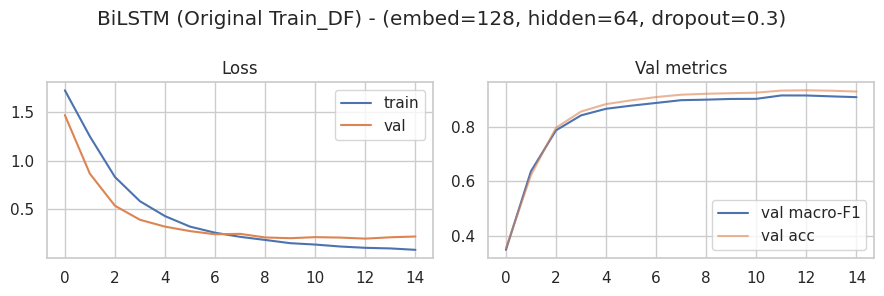

=== Validation BiLSTM (Original Train_DF) ===
Accuracy: 0.9310865191146881

Per-class precision/recall/F1:
  sadness     P=0.966  R=0.933  F1=0.949
  joy         P=0.965  R=0.933  F1=0.948
  love        P=0.828  R=0.977  F1=0.897
  anger       P=0.903  R=0.953  F1=0.927
  fear        P=0.923  R=0.853  F1=0.887
  surprise    P=0.815  R=0.938  F1=0.872

Macro / weighted F1: 0.9133466528798921 0.9315565205813765

               precision    recall  f1-score   support

     sadness      0.966     0.933     0.949       550
         joy      0.965     0.933     0.948       700
        love      0.828     0.977     0.897       173
       anger      0.903     0.953     0.927       274
        fear      0.923     0.853     0.887       211
    surprise      0.815     0.938     0.872        80

    accuracy                          0.931      1988
   macro avg      0.900     0.931     0.913      1988
weighted avg      0.934     0.931     0.932      1988



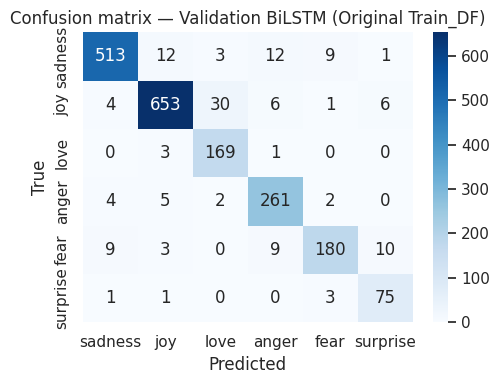


=== Training with Oversampled Train_DF ===
Class Weights: [1. 1. 1. 1. 1. 1.]
Epoch 01 train_loss=1.3422 val_loss=1.0728 val_acc=0.5689 val_macro_f1=0.6092
Epoch 02 train_loss=0.6038 val_loss=0.5724 val_acc=0.8124 val_macro_f1=0.8088
Epoch 03 train_loss=0.3261 val_loss=0.3649 val_acc=0.8818 val_macro_f1=0.8703
Epoch 04 train_loss=0.2024 val_loss=0.3211 val_acc=0.8994 val_macro_f1=0.8800
Epoch 05 train_loss=0.1443 val_loss=0.2901 val_acc=0.9049 val_macro_f1=0.8855
Epoch 06 train_loss=0.1021 val_loss=0.2818 val_acc=0.9145 val_macro_f1=0.8906
Epoch 07 train_loss=0.0801 val_loss=0.2677 val_acc=0.9150 val_macro_f1=0.8920
Epoch 08 train_loss=0.0621 val_loss=0.2723 val_acc=0.9175 val_macro_f1=0.8963
Epoch 09 train_loss=0.0501 val_loss=0.2761 val_acc=0.9200 val_macro_f1=0.9004
Epoch 10 train_loss=0.0445 val_loss=0.2708 val_acc=0.9225 val_macro_f1=0.8994
Epoch 12 train_loss=0.0304 val_loss=0.2940 val_acc=0.9215 val_macro_f1=0.8988
Early stopping at epoch 12 (no val macro-F1 improvement for 3 e

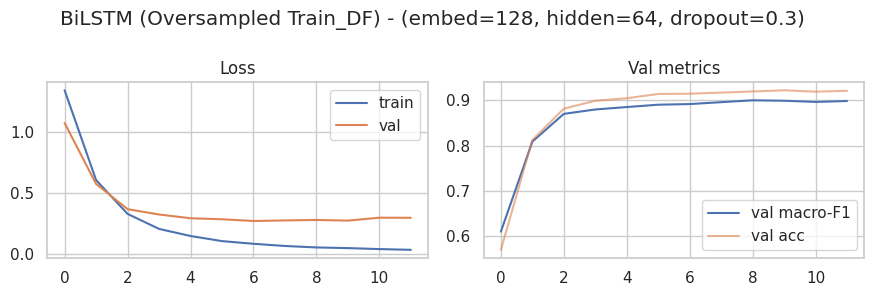

=== Validation BiLSTM (Oversampled Train_DF) ===
Accuracy: 0.920020120724346

Per-class precision/recall/F1:
  sadness     P=0.937  R=0.942  F1=0.939
  joy         P=0.968  R=0.909  F1=0.937
  love        P=0.816  R=0.948  F1=0.877
  anger       P=0.927  R=0.923  F1=0.925
  fear        P=0.873  R=0.877  F1=0.875
  surprise    P=0.793  R=0.912  F1=0.849

Macro / weighted F1: 0.9003685255007281 0.9207235749079555

               precision    recall  f1-score   support

     sadness      0.937     0.942     0.939       550
         joy      0.968     0.909     0.937       700
        love      0.816     0.948     0.877       173
       anger      0.927     0.923     0.925       274
        fear      0.873     0.877     0.875       211
    surprise      0.793     0.912     0.849        80

    accuracy                          0.920      1988
   macro avg      0.886     0.919     0.900      1988
weighted avg      0.923     0.920     0.921      1988



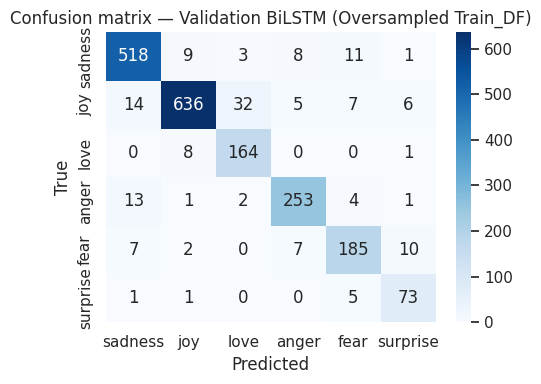


=== Training with Undersampled Train_DF ===
Class Weights: [1. 1. 1. 1. 1. 1.]
Epoch 01 train_loss=1.7862 val_loss=1.7712 val_acc=0.2384 val_macro_f1=0.2238
Epoch 02 train_loss=1.7454 val_loss=1.7282 val_acc=0.2495 val_macro_f1=0.2247
Epoch 03 train_loss=1.6379 val_loss=1.6414 val_acc=0.2777 val_macro_f1=0.2733
Epoch 04 train_loss=1.4246 val_loss=1.5489 val_acc=0.3360 val_macro_f1=0.3620
Epoch 05 train_loss=1.2281 val_loss=1.3486 val_acc=0.4457 val_macro_f1=0.4704
Epoch 06 train_loss=1.0591 val_loss=1.2666 val_acc=0.4909 val_macro_f1=0.5262
Epoch 07 train_loss=0.9261 val_loss=1.1883 val_acc=0.5423 val_macro_f1=0.5683
Epoch 08 train_loss=0.7856 val_loss=1.1033 val_acc=0.5845 val_macro_f1=0.6091
Epoch 09 train_loss=0.6704 val_loss=1.0735 val_acc=0.6187 val_macro_f1=0.6381
Epoch 10 train_loss=0.6056 val_loss=1.0367 val_acc=0.6268 val_macro_f1=0.6498
Epoch 11 train_loss=0.5292 val_loss=1.0172 val_acc=0.6509 val_macro_f1=0.6743
Epoch 12 train_loss=0.4669 val_loss=0.9843 val_acc=0.6635 val_

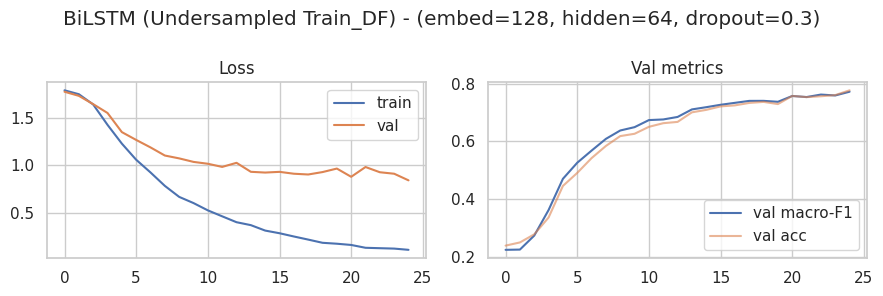

=== Validation BiLSTM (Undersampled Train_DF) ===
Accuracy: 0.7776659959758552

Per-class precision/recall/F1:
  sadness     P=0.785  R=0.764  F1=0.774
  joy         P=0.839  R=0.769  F1=0.802
  love        P=0.713  R=0.832  F1=0.768
  anger       P=0.729  R=0.785  F1=0.756
  fear        P=0.749  R=0.720  F1=0.734
  surprise    P=0.688  R=0.963  F1=0.802

Macro / weighted F1: 0.7727790754281543 0.7779224033886739

               precision    recall  f1-score   support

     sadness      0.785     0.764     0.774       550
         joy      0.839     0.769     0.802       700
        love      0.713     0.832     0.768       173
       anger      0.729     0.785     0.756       274
        fear      0.749     0.720     0.734       211
    surprise      0.688     0.963     0.802        80

    accuracy                          0.778      1988
   macro avg      0.750     0.805     0.773      1988
weighted avg      0.782     0.778     0.778      1988



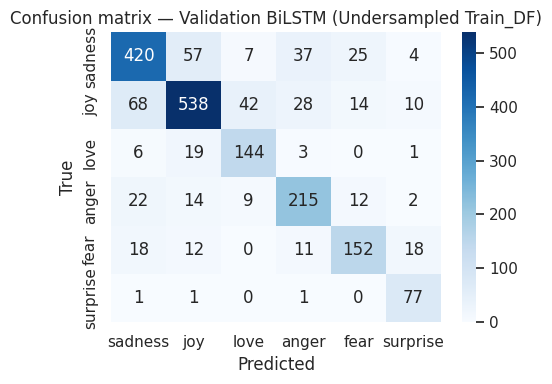


=== Training with Moderate Oversampled Train_DF ===
Class Weights: [0.6534777 0.5700967 1.4929773 1.4159696 1.4929773 1.4929773]
Epoch 01 train_loss=1.6092 val_loss=1.3765 val_acc=0.4125 val_macro_f1=0.4425
Epoch 02 train_loss=1.0474 val_loss=0.8902 val_acc=0.6393 val_macro_f1=0.6589
Epoch 03 train_loss=0.6686 val_loss=0.5550 val_acc=0.8184 val_macro_f1=0.8106
Epoch 04 train_loss=0.4513 val_loss=0.4181 val_acc=0.8521 val_macro_f1=0.8390
Epoch 05 train_loss=0.3227 val_loss=0.3647 val_acc=0.8838 val_macro_f1=0.8617
Epoch 06 train_loss=0.2462 val_loss=0.3233 val_acc=0.8969 val_macro_f1=0.8751
Epoch 07 train_loss=0.1896 val_loss=0.2955 val_acc=0.9064 val_macro_f1=0.8808
Epoch 08 train_loss=0.1559 val_loss=0.2671 val_acc=0.9100 val_macro_f1=0.8866
Epoch 09 train_loss=0.1303 val_loss=0.2570 val_acc=0.9145 val_macro_f1=0.8884
Epoch 10 train_loss=0.1078 val_loss=0.2712 val_acc=0.9190 val_macro_f1=0.8960
Epoch 12 train_loss=0.0820 val_loss=0.2477 val_acc=0.9185 val_macro_f1=0.8950
Epoch 13 tra

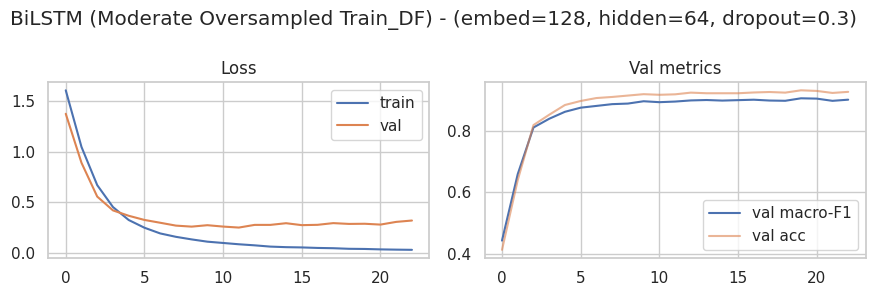

=== Validation BiLSTM (Moderate Oversampled Train_DF) ===
Accuracy: 0.93158953722334

Per-class precision/recall/F1:
  sadness     P=0.953  R=0.964  F1=0.958
  joy         P=0.962  R=0.946  F1=0.954
  love        P=0.863  R=0.913  F1=0.888
  anger       P=0.915  R=0.945  F1=0.930
  fear        P=0.923  R=0.801  F1=0.858
  surprise    P=0.779  R=0.925  F1=0.846

Macro / weighted F1: 0.9055839953294841 0.9315353574365495

               precision    recall  f1-score   support

     sadness      0.953     0.964     0.958       550
         joy      0.962     0.946     0.954       700
        love      0.863     0.913     0.888       173
       anger      0.915     0.945     0.930       274
        fear      0.923     0.801     0.858       211
    surprise      0.779     0.925     0.846        80

    accuracy                          0.932      1988
   macro avg      0.899     0.916     0.906      1988
weighted avg      0.933     0.932     0.932      1988



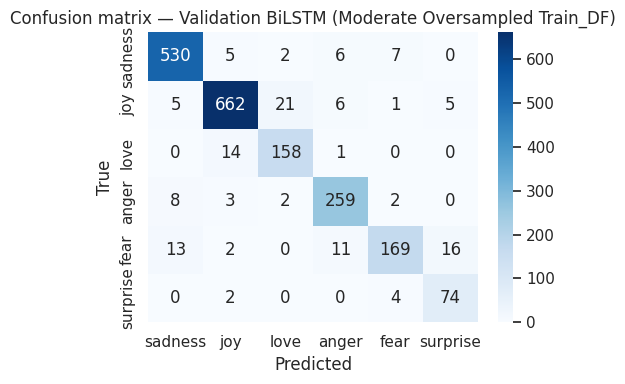

In [26]:
def get_class_weights(labels):
    class_counts = Counter(labels)
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    weights = torch.zeros(num_classes)
    for class_id, count in class_counts.items():
        # Inverse frequency weighting
        weights[class_id] = total_samples / (num_classes * count)
    return weights.to(device)


pad_id = vocab[PAD]

# Define the datasets to train and evaluate
datasets_to_test = [
    ("Original Train_DF", X_train, y_train, train_loader),
    ("Oversampled Train_DF", X_train_over, y_train_over, train_loader_over),
    ("Undersampled Train_DF", X_train_under, y_train_under, train_loader_under),
    ("Moderate Oversampled Train_DF", X_train_mod, y_train_mod, train_loader_mod),
]

all_trained_models = [] # To store models and their associated info for test evaluation

for name, X_train_data, y_train_data, current_train_loader in datasets_to_test:
    print(f"\n=== Training with {name} ===")
    # Set random seed for reproducibility for each model
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Calculate class weights for the current training data
    class_weights = get_class_weights(y_train_data)
    print("Class Weights:", class_weights.cpu().numpy())

    # Create a new BiLSTM model instance for each training scenario
    current_model = BiLSTMClassifier(
        vocab_size,
        embed_dim=128,
        hidden_dim=64,
        num_classes=num_classes,
        padding_idx=pad_id,
        bidirectional=True,
        dropout=0.3,
    ).to(device)

    # Train the model using the current training set and validate on the shared validation set
    hist, best_val_f1 = train_model(
        current_model,
        current_train_loader,
        val_loader,
        epochs=25,
        lr=1e-3,
        patience=3,
        class_weights=class_weights
    )

    print(f"Best val macro-F1 ({name}):", best_val_f1)
    plot_history(hist, title=f"BiLSTM ({name}) - (embed=128, hidden=64, dropout=0.3)")

    # Evaluate the trained model on the validation set
    _, yv_t, yv_p = evaluate(current_model, val_loader, nn.CrossEntropyLoss(weight=class_weights))
    cm, acc, maro_f1 = full_report(yv_t, yv_p, f"Validation BiLSTM ({name})")

    # Store the trained model and its class weights for later test evaluation
    all_trained_models.append((name, current_model, class_weights, cm, acc, maro_f1))

In [27]:
all_trained_models

[('Original Train_DF',
  BiLSTMClassifier(
    (embed): Embedding(7386, 128, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (lstm): LSTM(128, 64, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=128, out_features=6, bias=True)
  ),
  tensor([0.5703, 0.4975, 2.0504, 1.2357, 1.3772, 4.6819], device='cuda:0'),
  array([[513,  12,   3,  12,   9,   1],
         [  4, 653,  30,   6,   1,   6],
         [  0,   3, 169,   1,   0,   0],
         [  4,   5,   2, 261,   2,   0],
         [  9,   3,   0,   9, 180,  10],
         [  1,   1,   0,   0,   3,  75]]),
  0.9310865191146881,
  0.9133466528798921),
 ('Oversampled Train_DF',
  BiLSTMClassifier(
    (embed): Embedding(7386, 128, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (lstm): LSTM(128, 64, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=128, out_features=6, bias=True)
  ),
  tensor([1., 1., 1., 1., 1., 1.], device='cuda:0'),
  array([[518,   9,   3,   8,  11,   1],

## Performance Comparison

In [28]:
validation_summary = []

for name, model, class_weights, cm, acc, macro_f1 in all_trained_models:
    validation_summary.append({
        "Dataset": name,
        "Accuracy": acc,
        "Macro F1": macro_f1
    })

print("\n=== Validation Set Performance Summary ===")
summary_df = pd.DataFrame(validation_summary)
display(summary_df.set_index("Dataset").style.highlight_max(color='lightgreen', subset=['Accuracy', 'Macro F1']))


=== Validation Set Performance Summary ===


,Accuracy,Macro F1
Dataset,,
Original Train_DF,0.931087,0.913347
Oversampled Train_DF,0.920020,0.900369
Undersampled Train_DF,0.777666,0.772779
Moderate Oversampled Train_DF,0.931590,0.905584
